In [1]:
from models.TIEModel import TIEModel
import torch, math
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from models.TIEUtils import collator, TemporalDataset
from torch.utils.data import DataLoader

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
NUM_EPOCHS = 20
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 5
LOGGING_EPOCHS = 5
BASE_ENC_MODEL = "roberta-base"
HEADS = 6
WEIGHT_DECAY = 0.01
BATCH_SIZE = 16

In [3]:
cleandata_path = "D:\\GeoTKG\\cleandata\\tie\\"
train = TemporalDataset(cleandata_path + "combined.json")
eval = TemporalDataset(cleandata_path + "test.json")
#test = TemporalDataset(cleandata_path + "test.json")
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)
#test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = TIEModel(use_ca=True).to(device)

for p in model.enc.parameters(): p.requires_grad = False

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("enc.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("enc.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = len(train_loader)
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

def make_optim(unfrozen: bool):
    groups = []
    if unfrozen:
        groups.append({"params": model.enc.parameters(), "lr": ENC_LR})
    else:
        # keep enc group empty or skip entirely; either is fine
        pass
    nonenc = [p for n, p in model.named_parameters() if not n.startswith("enc.")]
    groups.append({"params": nonenc, "lr": NONENC_LR})
    return AdamW(groups, weight_decay=WEIGHT_DECAY)

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
global_step = 0
history = {#  Training
           "loss": [], "ner_loss":[], "et_loss":[], "ee_loss":[],
           #  Evaluation
           "ner_f1": [], "et_f1": [], "ee_f1": [], "eval_loss":[], "ner_eval_loss": [], "et_eval_loss": [], "ee_eval_loss": []}
enclr = []
nonenclr = []
for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    loss_sum = 0
    ner_loss_sum = 0
    et_loss_sum = 0
    ee_loss_sum = 0
    ration = 0
    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        ctx = (torch.autocast(device_type='cuda', dtype=torch.float16))
        with ctx:
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                ev_starts=batch["ev_starts"], ev_ends=batch["ev_ends"], ev_mask=batch["ev_mask"], e_sent_ids=batch["e_sent_ids"],
                ti_starts=batch["ti_starts"], ti_ends=batch["ti_ends"], ti_mask=batch["ti_mask"], t_sent_ids=batch["t_sent_ids"],
                ner_gold_labels=batch["ner_labels"],
                ev_ti_gold=batch["ev_ti_gold"],
                ee_rel_gold=batch["ee_triples"],
                ee_mask=batch["ee_mask"],
            )
            loss = out["loss"]
            loss_sum += loss.item()
            ner_loss_sum += out["ner_loss"].item()
            et_loss_sum += out["et_loss"].item()
            ee_loss_sum += out["ee_loss"].item()

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        prev_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        sched.step() if scaler.get_scale() <= prev_scale else None
        optimizer.zero_grad(set_to_none=True)
        global_step += 1

    print(f"Epoch {epoch+1} done. Avg Loss: {loss_sum / steps_per_epoch:.4f}")
    nonenclr.append(optimizer.param_groups[1]['lr'])
    enclr.append(optimizer.param_groups[0]['lr'])
    # ---- unfreeze after warmup epochs ----
    if epoch + 1 == WARMUP_EPOCHS:
        for p in model.enc.parameters():
            p.requires_grad = True
        # rebuild optimizer & scheduler for the remaining steps
        optimizer = make_optim(unfrozen=True)
        remaining_steps = steps_per_epoch * (NUM_EPOCHS - (epoch + 1))
        warmup_rem = 0
        sched = get_cosine_schedule_with_warmup(optimizer, warmup_rem, remaining_steps)

    # ---- validation ----
    if (epoch + 1) % LOGGING_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloader(eval_loader)
            history["ner_f1"].append(batch_evaluation["ner_f1"])
            history["et_f1"].append(batch_evaluation["et_f1"])
            history["ee_f1"].append(batch_evaluation["ee_f1"])
            history["eval_loss"].append(batch_evaluation["eval_loss"])
            history["ner_eval_loss"].append(batch_evaluation["ner_loss"])
            history["et_eval_loss"].append(batch_evaluation["et_loss"])
            history["ee_eval_loss"].append(batch_evaluation["ee_loss"])
            history["loss"].append(loss_sum / steps_per_epoch)
            history["ner_loss"].append(ner_loss_sum / steps_per_epoch)
            history["et_loss"].append(et_loss_sum / steps_per_epoch)
            history["ee_loss"].append(ee_loss_sum / steps_per_epoch)
        model.save(f"D:\\GeoTKG\\results\\tie_model\\tie_model_epoch{epoch+1}.pt")
        print(f"EPOCH{epoch+1} \nNER F1={batch_evaluation['ner_f1']:.4f},  ET F1={batch_evaluation['et_f1']:.4f},  EE F1={batch_evaluation['ee_f1']:.4f}\nTrain Loss={loss_sum / steps_per_epoch:.4f},    Eval Loss={batch_evaluation['eval_loss']:.4f}\nNER Eval Loss={batch_evaluation['ner_loss']:.4f}, NER Train Loss={ner_loss_sum / steps_per_epoch:.4f}\nET Eval Loss={batch_evaluation['et_loss']:.4f},  ET Train Loss={et_loss_sum / steps_per_epoch:.4f}\nEE Eval Loss={batch_evaluation['ee_loss']:.4f},  EE Train Loss={ee_loss_sum / steps_per_epoch:.4f}")

d:\GeoTKG\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1 done. Avg Loss: 6.3828
Epoch 2 done. Avg Loss: 2.5480
Epoch 3 done. Avg Loss: 2.2550
Epoch 4 done. Avg Loss: 2.1868
Epoch 5 done. Avg Loss: 2.1315


d:\GeoTKG\venv\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        DATE     0.7107    0.7391    0.7246      2403
    DURATION     0.1593    0.1921    0.1742       302
       EVENT     0.9326    0.8480    0.8883     16900
         SET     0.0000    0.0000    0.0000        16
        TIME     0.0000    0.0000    0.0000        47

   micro avg     0.8858    0.8219    0.8526     19668
   macro avg     0.3605    0.3558    0.3574     19668
weighted avg     0.8907    0.8219    0.8545     19668

              precision    recall  f1-score   support

         0.0     0.9931    0.8763    0.9310     88218
         1.0     0.1768    0.8127    0.2904      2883

    accuracy                         0.8743     91101
   macro avg     0.5849    0.8445    0.6107     91101
weighted avg     0.9672    0.8743    0.9108     91101

              precision    recall  f1-score   support

       AFTER     0.7615    0.9097    0.8291      6547
      BEFORE     0.7442    0.0627    0.1157       510
    CONTAINS     0.25

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       AFTER     0.7670    0.9200    0.8365      6547
      BEFORE     0.5222    0.0922    0.1567       510
    CONTAINS     0.6364    0.0209    0.0405       335
      DURING     0.4341    0.1639    0.2380       482
      EQUALS     0.6294    0.5730    0.5998      2042
    IDENTITY     0.5283    0.2353    0.3256       119
    OVERLAPS     0.0000    0.0000    0.0000        13

    accuracy                         0.7319     10048
   macro avg     0.5025    0.2865    0.3139     10048
weighted avg     0.7024    0.7319    0.6915     10048

EPOCH10 
NER F1=0.9761,  ET F1=0.8839,  EE F1=0.7319
Train Loss=2.1109,    Eval Loss=1.4539
NER Eval Loss=0.0238, NER Train Loss=0.0604
ET Eval Loss=0.6137,  ET Train Loss=1.0870
EE Eval Loss=0.8163,  EE Train Loss=0.9635
Epoch 11 done. Avg Loss: 2.0768
Epoch 12 done. Avg Loss: 2.0550
Epoch 13 done. Avg Loss: 2.0125
Epoch 14 done. Avg Loss: 1.9994
Epoch 15 done. Avg Loss: 1.9647
              precisi

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


EPOCH15 
NER F1=0.9788,  ET F1=0.8955,  EE F1=0.7364
Train Loss=1.9647,    Eval Loss=1.4107
NER Eval Loss=0.0382, NER Train Loss=0.0338
ET Eval Loss=0.6215,  ET Train Loss=1.0832
EE Eval Loss=0.7510,  EE Train Loss=0.8478
Epoch 16 done. Avg Loss: 1.9263
Epoch 17 done. Avg Loss: 1.9060
Epoch 18 done. Avg Loss: 1.8870
Epoch 19 done. Avg Loss: 1.8757
Epoch 20 done. Avg Loss: 1.8769
              precision    recall  f1-score   support

        DATE     0.9217    0.9359    0.9288      2403
    DURATION     0.7523    0.8046    0.7776       302
       EVENT     0.9907    0.9889    0.9898     16900
         SET     0.5789    0.6875    0.6286        16
        TIME     0.5522    0.7872    0.6491        47

   micro avg     0.9764    0.9788    0.9776     19668
   macro avg     0.7592    0.8408    0.7948     19668
weighted avg     0.9772    0.9788    0.9780     19668

              precision    recall  f1-score   support

         0.0     0.9937    0.8973    0.9431     88218
         1.0     0.2

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       AFTER     0.7765    0.9087    0.8374      6547
      BEFORE     0.5145    0.1392    0.2191       510
    CONTAINS     0.4505    0.1493    0.2242       335
      DURING     0.4968    0.1618    0.2441       482
      EQUALS     0.6241    0.5739    0.5980      2042
    IDENTITY     0.4272    0.3697    0.3964       119
    OVERLAPS     0.0000    0.0000    0.0000        13

    accuracy                         0.7329     10048
   macro avg     0.4699    0.3290    0.3599     10048
weighted avg     0.7028    0.7329    0.7022     10048

EPOCH20 
NER F1=0.9776,  ET F1=0.8951,  EE F1=0.7329
Train Loss=1.8769,    Eval Loss=1.4229
NER Eval Loss=0.0466, NER Train Loss=0.0215
ET Eval Loss=0.6091,  ET Train Loss=1.0694
EE Eval Loss=0.7672,  EE Train Loss=0.7860


In [6]:
import json
with open("results/tie_model/history.json", "w") as f:
    json.dump(history, f, indent=2)

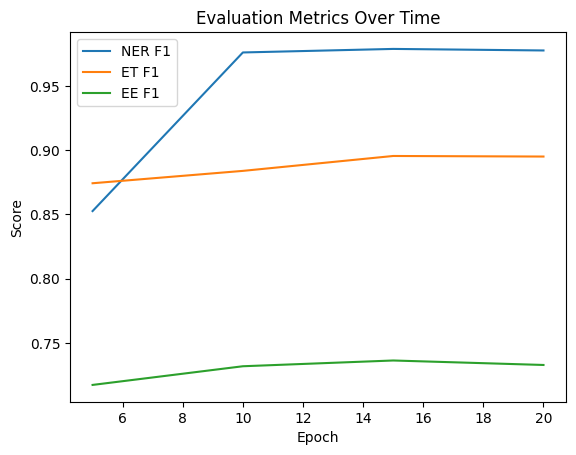

In [7]:
import matplotlib.pyplot as plt

x = list(range(5, 21, 5))

plt.plot(x, history["ner_f1"], label="NER F1")
plt.plot(x, history["et_f1"], label="ET F1")
plt.plot(x, history["ee_f1"], label="EE F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Evaluation Metrics Over Time")
plt.legend()
plt.show()

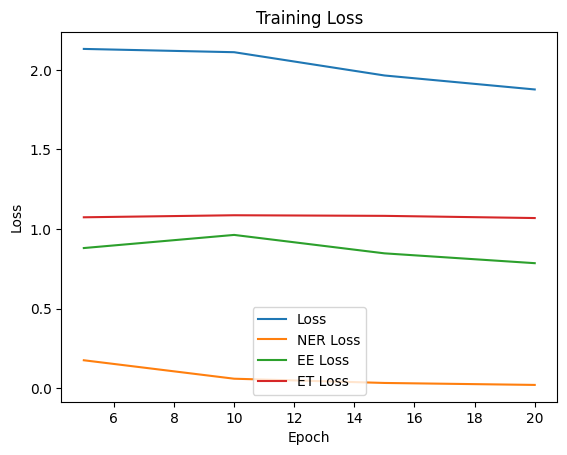

In [8]:
plt.plot(x, history["loss"], label="Loss")
plt.plot(x, history["ner_loss"], label="NER Loss")
plt.plot(x, history["ee_loss"], label="EE Loss")
plt.plot(x, history["et_loss"], label="ET Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

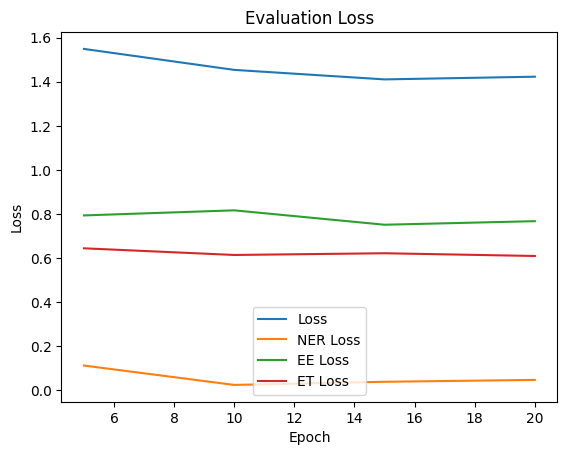

In [9]:
plt.plot(x, history["eval_loss"], label="Loss")
plt.plot(x, history["ner_eval_loss"], label="NER Loss")
plt.plot(x, history["ee_eval_loss"], label="EE Loss")
plt.plot(x, history["et_eval_loss"], label="ET Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evaluation Loss")
plt.show()

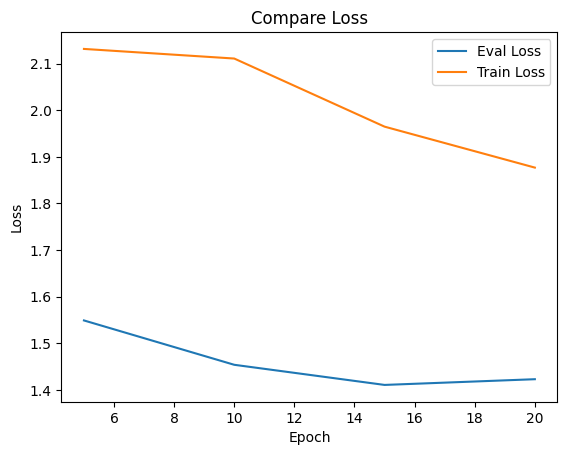

In [10]:
plt.plot(x, history["eval_loss"], label="Eval Loss")
plt.plot(x, history["loss"], label="Train Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare Loss")
plt.show()

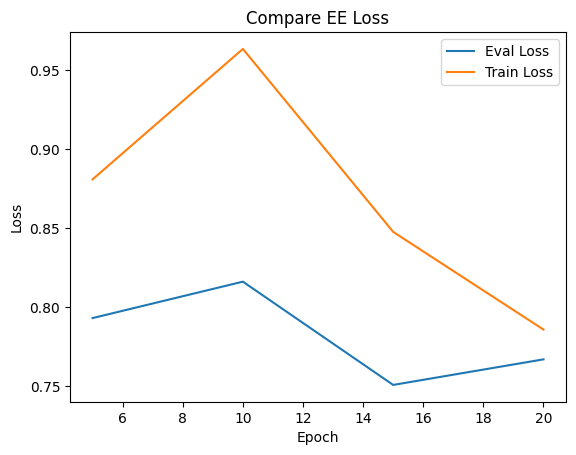

In [11]:
plt.plot(x, history["ee_eval_loss"], label="Eval Loss")
plt.plot(x, history["ee_loss"], label="Train Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare EE Loss")
plt.show()